# Bentley replication

Replicate the Bentley analysis.

# Preliminaries

In [46]:
# load some packages
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

# configuration
PROJECT_PATH = "./"
YEAR_MAX_CITATIONS = 2023
YEAR_MAX_PAPERS = 2013
YEAR_MIN_PAPERS = 1930
DROP_0BCITE_PAPERS = True

# font
plt.rcParams["text.usetex"] = False  # set True if LaTeX is installed
plt.rcParams["pdf.fonttype"] = 42

# Functions

In [47]:
def compute_bentley_cd_index(df, paper_year_col, paper_cd_col, paper_citations_total_col, max_year):

  # subset
  df = df[[paper_year_col, paper_cd_col, paper_citations_total_col]]

  # compute paper_citations_per_year
  df = df.assign(paper_citations_per_year = df[paper_citations_total_col]/(max_year-df[paper_year_col]))

  # compute cd_X_citations_per_year
  df = df.assign(cd_X_citations_per_year = df[paper_cd_col]*df["paper_citations_per_year"])

  # aggregate to year level
  yearly_df = df.groupby(paper_year_col).agg(r_weighted_cd = ("cd_X_citations_per_year", "sum"),
                                             normalise=("paper_citations_per_year", "sum"),
                                             cd_sum=(paper_cd_col, "sum"),
                                             cd_mean=(paper_cd_col, "mean"))
  
  # compute measure
  yearly_df = yearly_df.assign(r_weighted_cd_norm = yearly_df.r_weighted_cd/yearly_df.normalise)

  # return
  return yearly_df

# Load the data

## pubmed

In [48]:
# data from Bentley et al.
pubmed_df = pl.read_csv(PROJECT_PATH + "data/icite_metadata_filtered_withcds.csv",
                        columns=["pmid",
                                 "year",
                                 "is_research_article",
                                 "cd_5",
                                 "citation_count"])
pubmed_df = pubmed_df.to_pandas()

In [49]:
# pubmed_cdindex_df
#pubmed_cdindex_df = pl.read_csv(PROJECT_PATH + "data/pubmed_2018_cdindex_articles_cross_20210430.csv.gz")
#pubmed_cdindex_df = pubmed_cdindex_df.to_pandas()
#pubmed_cdindex_df

In [50]:
# subset
pubmed_df = pubmed_df[pubmed_df.is_research_article==True]
pubmed_df = pubmed_df[(pubmed_df.year>=YEAR_MIN_PAPERS) 
                    & (pubmed_df.year<=YEAR_MAX_PAPERS)]
pubmed_df = pubmed_df.dropna(subset=["cd_5"])

## sciscinet

In [51]:
# sciscinet_df
sciscinet_df = pl.read_csv(PROJECT_PATH + "data/SciSciNet_Papers.tsv",
                           separator="\t",
                           columns=["PaperID",
                                    "Year",
                                    "Disruption",
                                    "Reference_Count",
                                    "Citation_Count"])
sciscinet_df = sciscinet_df.to_pandas()
sciscinet_df

,PaperID,Year,Citation_Count,Reference_Count,Disruption
0,2789336,2008.0,1.0,13.0,-0.001927
1,9552966,2005.0,0.0,37.0,NaN
2,9694411,1994.0,0.0,0.0,NaN
3,14355006,2011.0,0.0,0.0,NaN
4,14558443,2014.0,14.0,11.0,-0.004613
...,...,...,...,...,...
134129183,3215499129,2021.0,0.0,14.0,NaN
134129184,3215845741,2021.0,0.0,33.0,NaN
134129185,3216186450,2021.0,0.0,0.0,NaN
134129186,3216762448,2022.0,0.0,33.0,NaN


In [52]:
# subset
sciscinet_df = sciscinet_df[(sciscinet_df.Year>=YEAR_MIN_PAPERS) 
                          & (sciscinet_df.Year<=YEAR_MAX_PAPERS)]
sciscinet_df = sciscinet_df.dropna(subset=["Disruption"])
if DROP_0BCITE_PAPERS:
  sciscinet_df = sciscinet_df[sciscinet_df.Reference_Count>0]

# Plots

In [55]:
# generate a color palette
colors = sns.color_palette("hls", 2)

## PubMed

In [56]:
# compute the Bentley et al. measure on pubmed for plotting
plot_pubmed_df = compute_bentley_cd_index(df=pubmed_df, 
                                          paper_year_col="year", 
                                          paper_cd_col="cd_5", 
                                          paper_citations_total_col="citation_count", 
                                          max_year=YEAR_MAX_CITATIONS)

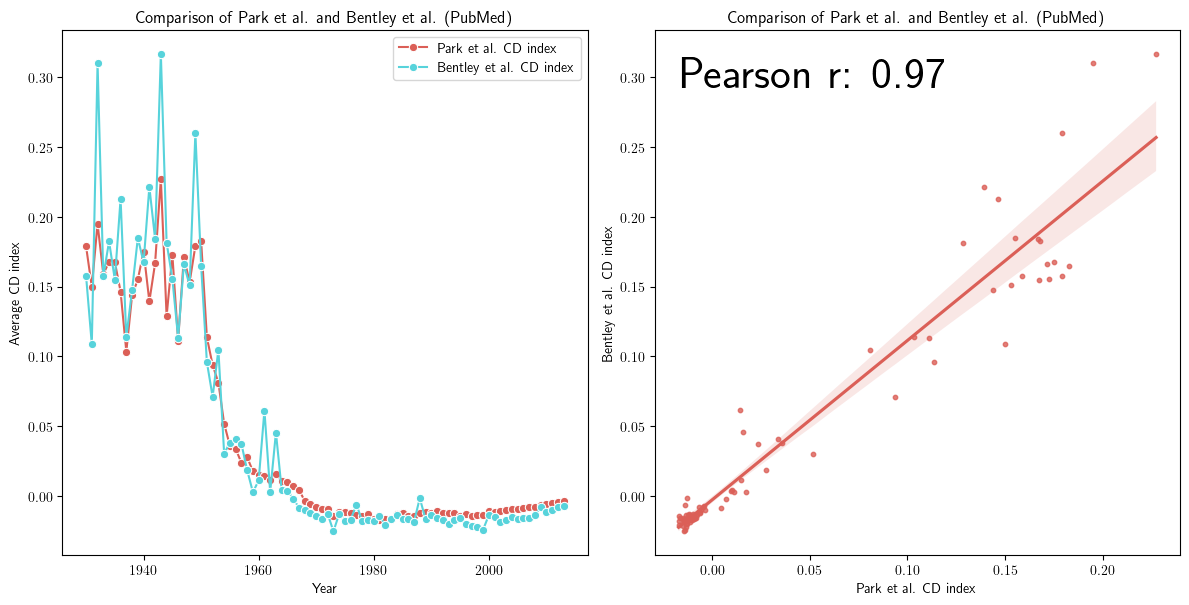

In [57]:
# initialize figure
fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs = axs.flat

# over time plot
sns.lineplot(x="year", 
             y="cd_mean", 
             data=plot_pubmed_df, 
             marker="o", 
             color=colors[0],
             label="Park et al. CD index",
             ax=axs[0])
sns.lineplot(x="year", 
             y="r_weighted_cd_norm", 
             data=plot_pubmed_df, 
             marker="o", 
             color=colors[1],
             label="Bentley et al. CD index",
             ax=axs[0])
axs[0].set_aspect(1/axs[0].get_data_ratio())
axs[0].set_xlabel("Year")
axs[0].set_ylabel("Average CD index")
axs[0].set_title("Comparison of Park et al. and Bentley et al. (PubMed)")

# add legend
axs[0].legend()

# scatterplot
sns.regplot(x="cd_mean",
            y="r_weighted_cd_norm",
            data=plot_pubmed_df,
            color=colors[0],
            ax=axs[1],
            scatter_kws={"s":10})
axs[1].set_aspect(1/axs[1].get_data_ratio())
axs[1].set_xlabel("Park et al. CD index")
axs[1].set_ylabel("Bentley et al. CD index")
axs[1].set_title("Comparison of Park et al. and Bentley et al. (PubMed)")

# add correlation coefficient
corr = plot_pubmed_df["cd_mean"].corr(plot_pubmed_df["r_weighted_cd_norm"])
axs[1].text(0.05, 0.95, 
            f"Pearson r: {corr:.2f}", 
            transform=axs[1].transAxes, 
            ha="left", 
            va="top", 
            fontsize=32)

# layout
plt.tight_layout()

# save
plt.savefig(PROJECT_PATH + "plots/park_bentley_pubmed_comparison.pdf")

## SciSciNet

In [58]:
# compute the Bentley et al. measure on sciscinet for plotting
plot_sciscinet_df = compute_bentley_cd_index(df=sciscinet_df, 
                                             paper_year_col="Year", 
                                             paper_cd_col="Disruption", 
                                             paper_citations_total_col="Citation_Count", 
                                             max_year=YEAR_MAX_CITATIONS)

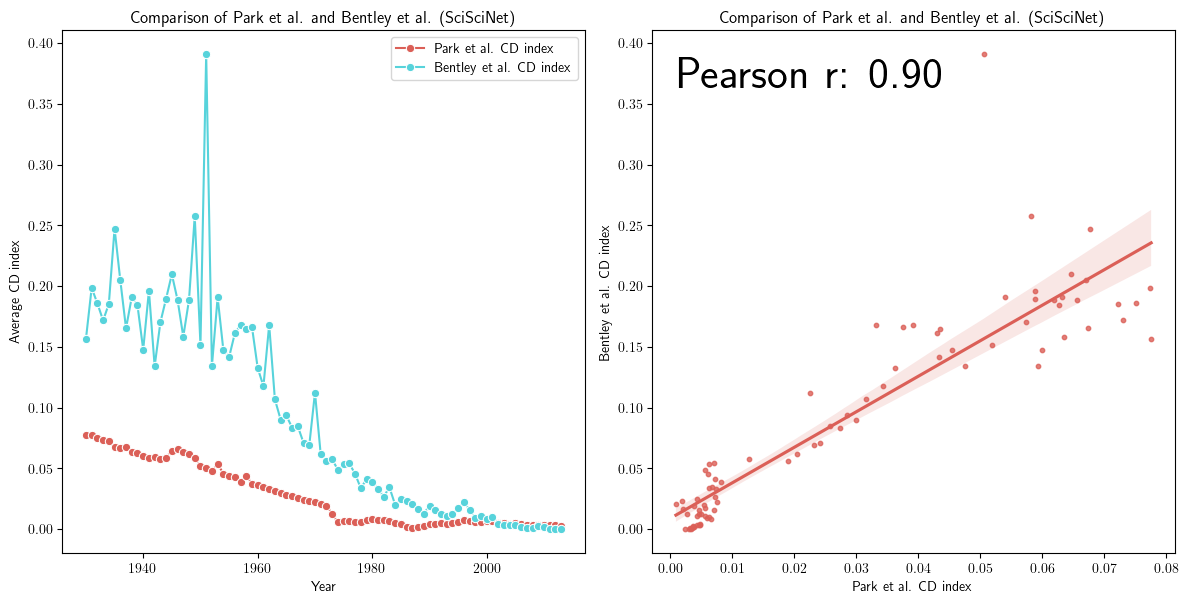

In [59]:
# initialize figure
fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs = axs.flat

# over time plot
sns.lineplot(x="Year", 
             y="cd_mean", 
             data=plot_sciscinet_df, 
             marker="o", 
             color=colors[0],
             label="Park et al. CD index",
             ax=axs[0])
sns.lineplot(x="Year", 
             y="r_weighted_cd_norm", 
             data=plot_sciscinet_df, 
             marker="o", 
             color=colors[1],
             label="Bentley et al. CD index",
             ax=axs[0])
axs[0].set_aspect(1/axs[0].get_data_ratio())
axs[0].set_xlabel("Year")
axs[0].set_ylabel("Average CD index")
axs[0].set_title("Comparison of Park et al. and Bentley et al. (SciSciNet)")

# add legend
axs[0].legend()

# scatterplot
sns.regplot(x="cd_mean",
            y="r_weighted_cd_norm",
            data=plot_sciscinet_df,
            color=colors[0],
            ax=axs[1],
            scatter_kws={"s":10})
axs[1].set_aspect(1/axs[1].get_data_ratio())
axs[1].set_xlabel("Park et al. CD index")
axs[1].set_ylabel("Bentley et al. CD index")
axs[1].set_title("Comparison of Park et al. and Bentley et al. (SciSciNet)")

# add correlation coefficient
corr = plot_sciscinet_df["cd_mean"].corr(plot_sciscinet_df["r_weighted_cd_norm"])
axs[1].text(0.05, 0.95, 
            f"Pearson r: {corr:.2f}", 
            transform=axs[1].transAxes, 
            ha="left", 
            va="top", 
            fontsize=32)

# layout
plt.tight_layout()

# save
plt.savefig(PROJECT_PATH + "plots/park_bentley_sciscinet_comparison.pdf")